In [1]:
import re
import spacy
import pandas as pd

from nltk.corpus import stopwords 
from nltk.stem.wordnet import WordNetLemmatizer
import string

# import numpy for matrix operation
import numpy as np

# Importing Gensim
import gensim
from gensim import corpora

In [2]:
# to suppress warnings
from warnings import filterwarnings
filterwarnings('ignore')

In [3]:
nlp = spacy.load('en_core_web_sm')

In [4]:
df=pd.read_csv("/kaggle/input/text-mining2/books_new (1).csv")
df

,Title,categories,description,User_id,review/score,review/text
0,"Word Biblical Commentary Vol. 5, Numbers (budd...",['Books'],NaN,A3LOZIGHG4LB3X,1.0,Word Biblical Commentary: Numbers is a worst c...
1,Castle Barebane : A Novel Of Suspense,['Books'],NaN,A89TL80GBGNUK,3.0,"""Castle Barebane"" was another experiment by Jo..."
2,Castle Barebane : A Novel Of Suspense,['Books'],NaN,A3IRBCCB3I5PPD,4.0,"Joan Aiken, daughter of poet Conrad Aiken, was..."
3,Mademoiselle liberte: Roman (French Edition),['Books'],NaN,A3CM5H0P9LNO58,5.0,"Looking for a novel in Nice last week, I came ..."
4,Mademoiselle liberte: Roman (French Edition),['Books'],NaN,A1CU6NTKULREFJ,3.0,Lorsque le feu de la passion devient incontrla...
...,...,...,...,...,...,...
568,ngeles fugaces (Falling Angels) (Spanish Edition),['Books'],NaN,A1L43KWWR05PCS,4.0,"This is the Spanish text edition of the book, ..."
569,Diccionario Enciclopedico de Terminos Tecnicos...,['Books'],NaN,A29DTN3W0WUBWT,3.0,When it was published in 1980 the Collazo was ...
570,Diccionario Enciclopedico de Terminos Tecnicos...,['Books'],NaN,A1DA8ESF6OXRS8,5.0,"We, technical translators, urgently need a ren..."
571,Diccionario Enciclopedico de Terminos Tecnicos...,['Books'],NaN,A3G94Q5H7LWUXD,5.0,"One of the best, if not the best technical dic..."


In [5]:
df_most_review = df[df['Title'].str.contains(r'\bThe Death of Outrage: Bill Clinton\b', regex=True)]

# Select the relevant columns
df_most_review = df_most_review[['Title','categories','review/score', 'review/text']]

# Display the filtered DataFrame
df_most_review
#fl=df_most_review.iloc[0]
#fl.to_dict()

,Title,categories,review/score,review/text
100,The Death of Outrage: Bill Clinton and the Ass...,['Books'],5.0,Out of all the polls that have been published ...
101,The Death of Outrage: Bill Clinton and the Ass...,['Books'],5.0,Maybe political pundits or media journalists w...
102,The Death of Outrage: Bill Clinton and the Ass...,['Books'],5.0,"Reading this, some 11 years after the Lewinsky..."
103,The Death of Outrage: Bill Clinton and the Ass...,['Books'],5.0,My outrage over the wide-spread scandals that ...
104,The Death of Outrage: Bill Clinton and the Ass...,['Books'],4.0,"Mr. Bennett, in lay person terms, takes apart ..."
...,...,...,...,...
243,The Death of Outrage: Bill Clinton and the Ass...,['Books'],5.0,This is a fantastic book that puts Bill Clinto...
244,The Death of Outrage: Bill Clinton and the Ass...,['Books'],1.0,Having read through Bennett's sanctimonious ti...
245,The Death of Outrage: Bill Clinton and the Ass...,['Books'],5.0,Bill Bennett's documentary of the shameful act...
246,The Death of Outrage: Bill Clinton and the Ass...,['Books'],3.0,"Great title, but unfortunately the book was wr..."


In [6]:
df_most_review['review/score'].value_counts().sort_index

<bound method Series.sort_index of review/score
5.0    73
1.0    45
4.0    21
3.0     6
2.0     3
Name: count, dtype: int64>

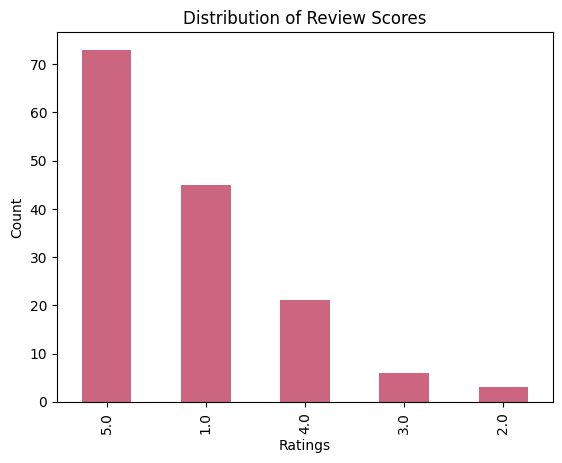

In [7]:
import matplotlib.pyplot as plt

#Bar plot to visualize the total counts of each rating
dusty_rose_pink = (0.8, 0.4, 0.5)
df_most_review['review/score'].value_counts().plot.bar(color = dusty_rose_pink)
plt.title('Distribution of Review Scores')
plt.xlabel('Ratings')
plt.ylabel('Count')
plt.show()

In [8]:
# Filter the DataFrame for rows where 'review/score' is 1, 2, or 3
df_most_review_1 = df_most_review[df_most_review['review/score'].isin([1])]

# Reset the index to get a sequential Id and drop the old index
df_most_review_1 = df_most_review_1.reset_index(drop=True)

# Assign a new Id based on the new index
df_most_review_1['Id'] = df_most_review_1.index + 1
df_most_review_1

,Title,categories,review/score,review/text,Id
0,The Death of Outrage: Bill Clinton and the Ass...,['Books'],1.0,How does it feel to have your life destroyed b...,1
1,The Death of Outrage: Bill Clinton and the Ass...,['Books'],1.0,Reagan and Bush told no lies? Keep dreaming,2
2,The Death of Outrage: Bill Clinton and the Ass...,['Books'],1.0,In this era of narrowmindedness and conservati...,3
3,The Death of Outrage: Bill Clinton and the Ass...,['Books'],1.0,If the '80's were the Al Frankin decade then t...,4
4,The Death of Outrage: Bill Clinton and the Ass...,['Books'],1.0,I thought that Clinton should have resigned a ...,5
5,The Death of Outrage: Bill Clinton and the Ass...,['Books'],1.0,The best thing that can be said about Bill Ben...,6
6,The Death of Outrage: Bill Clinton and the Ass...,['Books'],1.0,Wouldn't it be a better idea to issue a hollow...,7
7,The Death of Outrage: Bill Clinton and the Ass...,['Books'],1.0,Methinks the self-proclaimed pillar of virtue ...,8
8,The Death of Outrage: Bill Clinton and the Ass...,['Books'],1.0,Mr. Bennett cannot get over or get used to the...,9
9,The Death of Outrage: Bill Clinton and the Ass...,['Books'],1.0,Gotta give Bennnet SOME credit - he sure knows...,10


In [9]:
import nltk
from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import RegexpTokenizer
from stop_words import get_stop_words
from nltk.stem.wordnet import WordNetLemmatizer

In [10]:
!unzip /usr/share/nltk_data/corpora/wordnet.zip -d /usr/share/nltk_data/corpora/

Archive:  /usr/share/nltk_data/corpora/wordnet.zip
   creating: /usr/share/nltk_data/corpora/wordnet/
  inflating: /usr/share/nltk_data/corpora/wordnet/lexnames  
  inflating: /usr/share/nltk_data/corpora/wordnet/data.verb  
  inflating: /usr/share/nltk_data/corpora/wordnet/index.adv  
  inflating: /usr/share/nltk_data/corpora/wordnet/adv.exc  
  inflating: /usr/share/nltk_data/corpora/wordnet/index.verb  
  inflating: /usr/share/nltk_data/corpora/wordnet/cntlist.rev  
  inflating: /usr/share/nltk_data/corpora/wordnet/data.adj  
  inflating: /usr/share/nltk_data/corpora/wordnet/index.adj  
  inflating: /usr/share/nltk_data/corpora/wordnet/LICENSE  
  inflating: /usr/share/nltk_data/corpora/wordnet/citation.bib  
  inflating: /usr/share/nltk_data/corpora/wordnet/noun.exc  
  inflating: /usr/share/nltk_data/corpora/wordnet/verb.exc  
  inflating: /usr/share/nltk_data/corpora/wordnet/README  
  inflating: /usr/share/nltk_data/corpora/wordnet/index.sense  
  inflating: /usr/share/nltk_data

In [11]:
stop_words=stopwords.words('english')
pattern = r'\b[^\d\W]+\b'
tokenizer = RegexpTokenizer(pattern)
lemmatizer = WordNetLemmatizer()

In [19]:
remove_words = ['bennett','reagan','bush','clinton','quot','bill','book','one','mr','outrage','would']
#remove_words=[]

In [20]:
# list for tokenized documents in loop
from nltk.corpus import wordnet
texts_1score = []

def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN
# loop through document list
for i in df_most_review_1['review/text'].items():
    # clean and tokenize document string
    raw = str(i[1]).lower()
    tokens = tokenizer.tokenize(raw)

    # remove stop words from tokens
    stopped_tokens = [raw for raw in tokens if not raw in stop_words]
    
    # remove stop words from tokens
    stopped_tokens_new = [raw for raw in stopped_tokens if not raw in remove_words]
    
    # POS tagging
    pos_tags = nltk.pos_tag(stopped_tokens_new)
    
    # Lemmatize tokens with POS tags
    lemma_tokens = [lemmatizer.lemmatize(token, get_wordnet_pos(tag)) for token, tag in pos_tags]
    
    # lemmatize tokens
    #lemma_tokens = [lemmatizer.lemmatize(tokens) for tokens in stopped_tokens_new]
    
    # remove word containing only single char
    new_lemma_tokens = [raw for raw in lemma_tokens if not len(raw) == 1]
    
    # add tokens to list
    texts_1score .append(new_lemma_tokens)

# sample data
print(texts_1score [0])

['feel', 'life', 'destroyed', 'people', 'make', 'hay', 'personal', 'weakness', 'go', 'around', 'come', 'around', 'billy', 'boy', 'feel', 'pain', 'man', 'never', 'able', 'feel', 'anyone', 'else', 'well', 'men', 'mock', 'feel', 'pain', 'others', 'maybe', 'understand', 'forgiveness', 'tolerance', 'understand', 'virtue', 'hypocrisy', 'seem', 'reason', 'burn', 'book', 'smash', 'dixie', 'chick', 'cd', 'least', 'chick', 'speak', 'conviction', 'calculation']


In [21]:
from wordcloud import WordCloud

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

Top 10 Complaints:
          term     tfidf
26       moral  5.576469
48        well  4.386759
36  republican  4.064762
27    morality  3.820256
31      people  3.672896
49       write  3.643636
21        like  3.473794
19         lie  3.104052
28       never  3.103379
37       right  2.999245


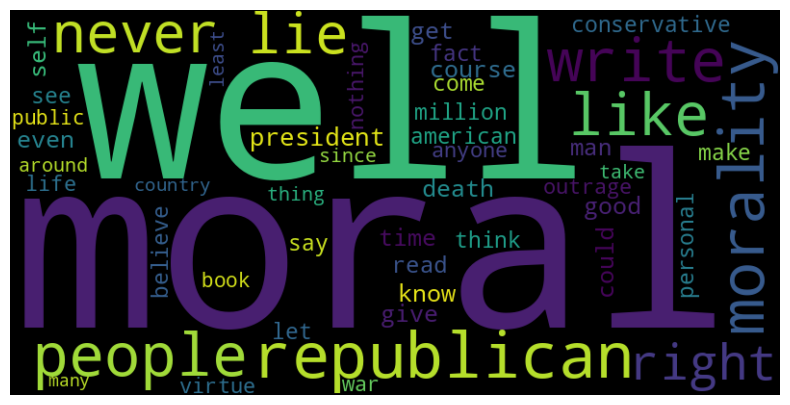

In [24]:
texts_tf_idf = [" ".join(doc) for doc in texts_1score]
# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=50)
tfidf_matrix = vectorizer.fit_transform(texts_tf_idf)
terms = vectorizer.get_feature_names_out()

# Sum TF-IDF scores for each term
sums = tfidf_matrix.sum(axis=0)
data = []
for col, term in enumerate(terms):
    data.append((term, sums[0, col]))

ranking = pd.DataFrame(data, columns=['term', 'tfidf'])
ranking = ranking.sort_values('tfidf', ascending=False)

# Display the top 10 complaints
print("Top 10 Complaints:")
print(ranking.head(10))

# Visualize common complaints with a word cloud
wordcloud = WordCloud(width=800, height=400, background_color='black').generate_from_frequencies(dict(data))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

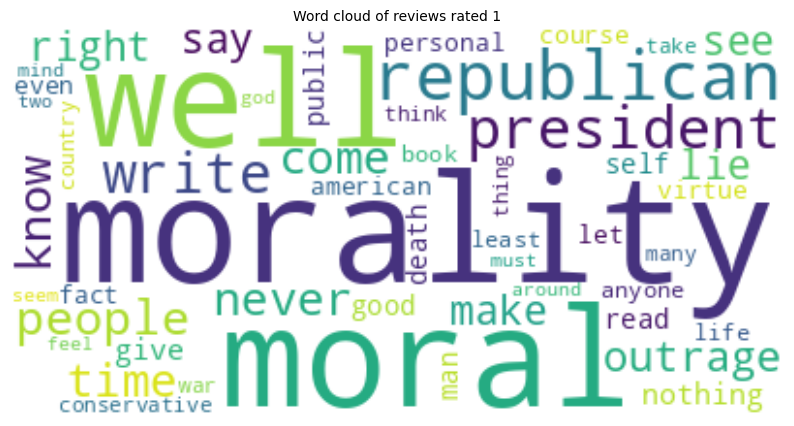

In [16]:
flat_text = ' '.join([token for sublist in texts_1score for token in sublist])

# Initialize wordcloud object
wc = WordCloud(background_color='white', max_words=50)

# Generate and plot wordcloud
plt.figure(figsize=(10, 10))
plt.imshow(wc.generate(flat_text), interpolation='bilinear')
plt.title('Word cloud of reviews rated 1', fontsize=10)
plt.axis('off')
plt.show()

In [16]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [17]:
!pip install nltk twython tqdm

In [18]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm

sia = SentimentIntensityAnalyzer()

In [19]:
res = {}
for i, row in tqdm(df_most_review_1.iterrows(), total=len(df)):
    text = row['review/text']
    myid = row['Id']
    res[myid] = sia.polarity_scores(text)

  0%|          | 0/573 [00:00<?, ?it/s]

In [20]:
vaders = pd.DataFrame(res).T
vaders = vaders.reset_index().rename(columns={'index': 'Id'})
vaders = vaders.merge(df_most_review_1, how='left')
vaders.head()

,Id,neg,neu,pos,compound,Title,categories,review/score,review/text
0,1,0.116,0.779,0.105,-0.4926,The Death of Outrage: Bill Clinton and the Ass...,['Books'],1.0,How does it feel to have your life destroyed b...
1,2,0.455,0.545,0.000,-0.6124,The Death of Outrage: Bill Clinton and the Ass...,['Books'],1.0,Reagan and Bush told no lies? Keep dreaming
2,3,0.106,0.765,0.129,0.5093,The Death of Outrage: Bill Clinton and the Ass...,['Books'],1.0,In this era of narrowmindedness and conservati...
3,4,0.000,1.000,0.000,0.0000,The Death of Outrage: Bill Clinton and the Ass...,['Books'],1.0,If the '80's were the Al Frankin decade then t...
4,5,0.209,0.665,0.126,-0.8857,The Death of Outrage: Bill Clinton and the Ass...,['Books'],1.0,I thought that Clinton should have resigned a ...


In [21]:
df = pd.DataFrame(vaders)

In [26]:
pd.set_option('display.max_columns', None)  
pd.set_option('display.expand_frame_repr', False)  
pd.set_option('display.max_colwidth', None)  
df.iloc[8]

Id                                                                                                                                                                                                                                                                                               9
neg                                                                                                                                                                                                                                                                                           0.07
neu                                                                                                                                                                                                                                                                                          0.839
pos                                                                                                                            

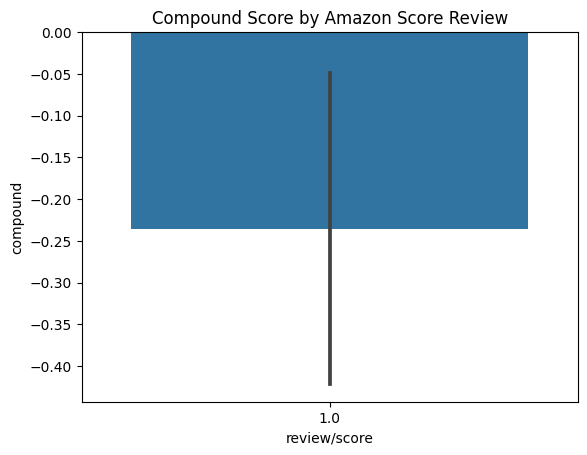

In [17]:
import seaborn as sns
ax = sns.barplot(data=vaders, x='review/score', y='compound')
ax.set_title('Compound Score by Amazon Score Review')
plt.show()

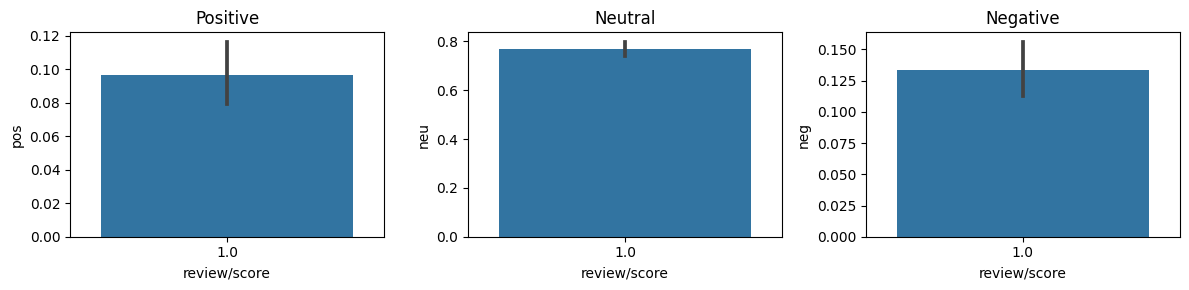

In [18]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3))
sns.barplot(data=vaders, x='review/score', y='pos', ax=axs[0])
sns.barplot(data=vaders, x='review/score', y='neu', ax=axs[1])
sns.barplot(data=vaders, x='review/score', y='neg', ax=axs[2])
axs[0].set_title('Positive')
axs[1].set_title('Neutral')
axs[2].set_title('Negative')
plt.tight_layout()
plt.show()